In [1]:
import numpy as np
import torch
from torch import nn

In [2]:
# Dataset: https://github.com/atilsamancioglu/Desert101DataSet

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!cp -r "/content/drive/MyDrive/Deep Learning Bootcamp/Computer Vision/desert101" "/content/desert101"

In [5]:
from pathlib import Path
import os

image_path = Path("/content/desert101")

train_dir = image_path / "train"
test_dir = image_path / "test"

In [6]:
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [7]:
check_data(image_path)

# of directories: 3 and 0 images in '/content/desert101'.
# of directories: 4 and 0 images in '/content/desert101/test'.
# of directories: 0 and 19 images in '/content/desert101/test/cannoli'.
# of directories: 0 and 20 images in '/content/desert101/test/cup_cakes'.
# of directories: 0 and 19 images in '/content/desert101/test/baklava'.
# of directories: 0 and 19 images in '/content/desert101/test/donuts'.
# of directories: 2 and 0 images in '/content/desert101/desert101'.
# of directories: 4 and 0 images in '/content/desert101/desert101/test'.
# of directories: 0 and 19 images in '/content/desert101/desert101/test/cannoli'.
# of directories: 0 and 20 images in '/content/desert101/desert101/test/cup_cakes'.
# of directories: 0 and 19 images in '/content/desert101/desert101/test/baklava'.
# of directories: 0 and 19 images in '/content/desert101/desert101/test/donuts'.
# of directories: 4 and 0 images in '/content/desert101/desert101/train'.
# of directories: 0 and 79 images in '/content

Image path: /content/desert101/train/donuts/2249805.jpg
Image class: donuts
Image size: (512, 512)


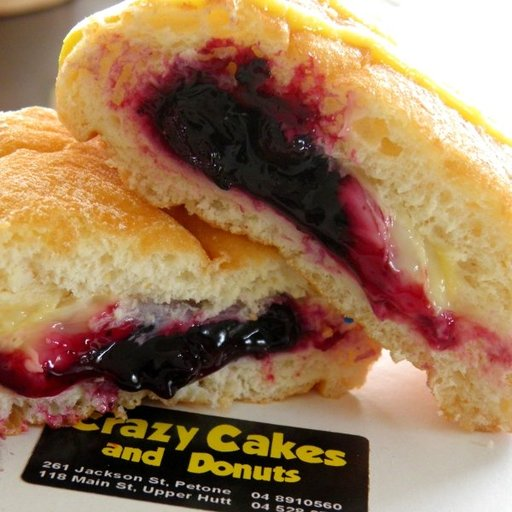

In [8]:
import random
from PIL import Image

random.seed(42)

# Tüm jpg görselleri alıyoruz
image_path_list = list(image_path.glob("*/*/*.jpg"))

# Rastgele bir görsel seçiyoruz
random_image_path = random.choice(image_path_list)

# Görselin sınıfını klasör adından alıyoruz
image_class = random_image_path.parent.stem

# Görseli açıyoruz
img = Image.open(random_image_path)

print(f"Image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image size: {img.size}")

img

# Data Augmentation

**Data augmentation**, eğitim veri setindeki görüntülere çeşitli dönüşümler uygulayarak modelin daha farklı örnekler görmesini sağlayan bir tekniktir.

Örneğin bir tatlı sınıflandırma probleminde aynı baklava, cheesecake veya kurabiye görseli farklı açılardan, farklı kırpılmış bölgelerden ya da farklı parlaklık değerleriyle modele gösterilebilir. Böylece model yalnızca ezber yapmak yerine, sınıfa ait daha genel özellikleri öğrenmeye çalışır.

Data augmentation genellikle sadece **training data** üzerinde uygulanır. Çünkü modelin eğitim sırasında daha çeşitli örnekler görmesini isteriz. Test verisinde ise görüntüleri değiştirmek yerine modeli gerçek ve sabit veriler üzerinde değerlendirmek daha doğru olur.

Yaygın kullanılan augmentation işlemlerinden bazıları şunlardır:

- `RandomHorizontalFlip`: Görüntüyü rastgele yatay çevirir.
- `RandomRotation`: Görüntüyü belirli açılar arasında döndürür.
- `RandomResizedCrop`: Görüntüyü rastgele kırpar ve yeniden boyutlandırır.
- `ColorJitter`: Parlaklık, kontrast, doygunluk gibi renk özelliklerini değiştirir.
- `RandomAffine`: Görüntüye kaydırma, döndürme veya ölçekleme gibi dönüşümler uygular.

PyTorch tarafında bu işlemler `torchvision.transforms` ile kolayca uygulanabilir. Birden fazla dönüşüm `transforms.Compose()` içinde birleştirilerek sırayla çalıştırılabilir.

Data augmentation özellikle veri seti küçük olduğunda veya modelin overfitting yapma ihtimali yüksek olduğunda oldukça faydalıdır. Ancak dönüşümler seçilirken dikkatli olunmalıdır. Çünkü görüntüyü fazla bozmak, sınıf bilgisini kaybettirebilir. Örneğin bir tatlı görselini çok fazla döndürmek, aşırı kırpmak veya renklerini gerçekçi olmayacak şekilde değiştirmek modelin öğrenmesini zorlaştırabilir.

Bu çalışmada data augmentation, tatlı görsellerinin farklı varyasyonlarını oluşturarak modelin daha dayanıklı ve genellenebilir öğrenmesine yardımcı olmak için kullanılacaktır.

---

## Paper Kısaca Ne Anlatıyor?

Paylaşılan makale **“TrivialAugment: Tuning-free Yet State-of-the-Art Data Augmentation”** adlı çalışmadır.

Bu paper, görüntü sınıflandırma problemlerinde data augmentation işlemini daha basit hale getirmeyi amaçlar. Normalde bazı otomatik augmentation yöntemleri, hangi dönüşümlerin kullanılacağını ve bu dönüşümlerin ne kadar uygulanacağını bulmak için ek ayar, arama veya tuning süreci gerektirir.

**TrivialAugment** ise bu süreci oldukça sadeleştirir. Her görüntü için rastgele bir augmentation işlemi seçer ve uygular. Yani karmaşık bir policy search veya uzun bir hiperparametre ayarlama süreci kullanmaz.

Makalenin temel fikri şudur:

> Data augmentation için her zaman karmaşık yöntemlere gerek olmayabilir. Basit, ayarsız ve rastgele seçilen dönüşümler bile görüntü sınıflandırma modellerinde güçlü sonuçlar verebilir.

Bu çalışma, basit augmentation yaklaşımlarının da modelin genelleme başarısını artırabileceğini göstermesi açısından önemlidir. Özellikle küçük veya orta ölçekli projelerde, karmaşık augmentation stratejileri yerine daha sade yöntemlerin de etkili olabileceğini gösterir.

---

## Kaynaklar

- PyTorch Transforms Documentation: https://docs.pytorch.org/vision/0.9/transforms.html
- PyTorch Transform Illustrations: https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html
- Paper - TrivialAugment: Tuning-free Yet State-of-the-Art Data Augmentation: https://arxiv.org/abs/2103.10158

In [9]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [10]:
data_transform = transforms.Compose([
    # Görüntüleri 64x64 boyutuna yeniden boyutlandırıyoruz.
    # Bu işlem görüntü kalitesini bir miktar düşürebilir.
    # Bu bizim tercihimiz; istersek orijinal boyutta da bırakabiliriz.
    # Ancak orijinal boyutta çalışmak daha fazla hesaplama gücü gerektirebilir.
    transforms.Resize((64, 64)),

    # Görüntüleri rastgele yatay olarak çeviriyoruz.
    transforms.RandomHorizontalFlip(p=0.4),

    # Data Augmentation işlemi uyguluyoruz.
    transforms.TrivialAugmentWide(),

    # Görüntüyü torch.Tensor formatına çeviriyoruz.
    transforms.ToTensor()
])

In [11]:
# Transformları uygulamak ve verileri daha sonra DataLoader içine yükleyebilmek için
# torchvision içindeki ImageFolder yapısını kullanacağız.

train_data = datasets.ImageFolder(root = train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root = test_dir, transform=data_transform)

In [12]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: /content/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [13]:
# sınıf isimleri
class_name = train_data.classes
class_name

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [14]:
len(train_data), len(test_data)

(316, 77)

In [15]:
# Artık bu görüntü verilerini DataLoader'a verebiliriz.
# Böylece verimizi sinir ağına uygun şekilde hazır hale getirmiş oluruz.

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE, # Her batch içinde kaç örnek olacağını belirtir
                              num_workers=NUM_WORKERS, # Veri yükleme için kaç alt işlem kullanılacağını belirtir, Daha yüksek değer genellikle daha hızlı veri yükleme sağlayabilir: NUM_WORKERS=2
                              shuffle=True) # Eğitim verisini karıştırır

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False) # Test verisini karıştırmaya gerek yoktur

In [16]:
print(train_dataloader.dataset[0][0].shape)
train_dataloader.dataset[0][0]

torch.Size([3, 64, 64])


tensor([[[0.4549, 0.4510, 0.4784,  ..., 0.0000, 0.0000, 0.0000],
         [0.4706, 0.4471, 0.5294,  ..., 0.0000, 0.0000, 0.0000],
         [0.5490, 0.4667, 0.5843,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.8000, 0.8196, 0.8353,  ..., 0.9333, 0.9333, 0.7882],
         [0.8196, 0.8039, 0.7922,  ..., 0.9843, 0.9922, 0.8863],
         [0.8196, 0.8510, 0.8314,  ..., 0.9608, 0.9922, 0.9765]],

        [[0.3216, 0.3137, 0.3451,  ..., 0.0000, 0.0000, 0.0000],
         [0.3569, 0.3333, 0.4078,  ..., 0.0000, 0.0000, 0.0000],
         [0.4078, 0.3412, 0.4549,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.5451, 0.5725, 0.5961,  ..., 0.7804, 0.7922, 0.6078],
         [0.5765, 0.5686, 0.5569,  ..., 0.8510, 0.9137, 0.7137],
         [0.6000, 0.6431, 0.6314,  ..., 0.8000, 0.9176, 0.8745]],

        [[0.0902, 0.0824, 0.0980,  ..., 0.0000, 0.0000, 0.0000],
         [0.1137, 0.1020, 0.1490,  ..., 0.0000, 0.0000, 0.0000],
         [0.1059, 0.1059, 0.1765,  ..., 0.0000, 0.0000, 0.

## Görüntünün Tensor Formatı

Bu çıktı, veri setindeki bir görselin **sayısal olarak temsil edilmiş halidir**.

```python
print(train_dataloader.dataset[0][0].shape)
train_dataloader.dataset[0][0]
```

Shape çıktısı:

```text
torch.Size([3, 64, 64])
```

Buradaki yapı şu anlama gelir:

- `3`: RGB renk kanallarıdır.
- `64`: Görüntünün yüksekliğidir.
- `64`: Görüntünün genişliğidir.

Yani görsel artık modelin anlayabileceği şu formattadır:

```text
[renk kanalı, yükseklik, genişlik]
```

Tensor içinde görülen sayılar, piksellerin sayısal değerleridir.  
`ToTensor()` işlemi piksel değerlerini genellikle **0 ile 1 arasına** ölçekler.

Kısaca model görseli bizim gibi resim olarak görmez. Görseli, RGB kanallarına ayrılmış sayısal bir tensor olarak işler ve öğrenmeyi bu sayılar üzerinden yapar.

In [17]:
# Verimiz artık hazır.
# Şimdi sinir ağını oluşturmaya geçelim ve modelin çalışıp çalışmadığını görelim.

In [18]:
class DesertClassifier(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels = input_shape,
            out_channels = hidden_units,
            kernel_size = 3,
            padding = 1,
            stride = 1),
        nn.ReLU(),

        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            padding = 1,
            stride = 1),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 1
        ),
        nn.ReLU(),

        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 1
        ),
        nn.ReLU(),

        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units * 16 * 16, out_features = output_shape)
    )

  def forward(self, x):
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [19]:
model_0 = DesertClassifier(input_shape = 3, hidden_units = 32, output_shape = len(class_name))
model_0

DesertClassifier(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=4, bias=True)
  )
)

In [20]:
# !pip install torchinfo

In [21]:
from torchinfo import summary

In [22]:
summary(model_0, input_size = [1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [23]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):
  # Modeli eğitim moduna alıyoruz
  model.train()

  # Train loss ve train accuracy değerlerini başlatıyoruz
  train_loss = 0
  train_acc = 0

  # DataLoader içindeki batch'ler üzerinde döngü kuruyoruz
  for batch, (X, y) in enumerate(dataloader):

    # 1. Forward pass
    y_pred = model(X)

    # 2. Loss değerini hesapla ve toplam train loss'a ekle
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    # 3. Optimizer gradientlerini sıfırla
    optimizer.zero_grad()

    # 4. Backpropagation işlemini yap
    loss.backward()

    # 5. Optimizer ile model parametrelerini güncelle
    optimizer.step()

    # Batch bazında accuracy hesapla ve toplam train accuracy değerine ekle
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  # Ortalama train loss ve train accuracy değerlerini hesapla
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [24]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module):

  # Modeli değerlendirme moduna alıyoruz
  model.eval()

  test_loss = 0
  test_acc = 0

  # Test aşamasında gradient hesaplamaya gerek yoktur
  with torch.inference_mode():

    # DataLoader içindeki batch'ler üzerinde döngü kuruyoruz
    for batch, (X, y) in enumerate(dataloader):

      # 1. Forward pass
      test_preds_logits = model(X)

      # 2. Loss değerini hesapla ve toplam test loss'a ekle
      loss = loss_fn(test_preds_logits, y)
      test_loss += loss.item()

      # Accuracy hesapla ve toplam test accuracy değerine ekle
      test_preds_labels = torch.argmax(torch.softmax(test_preds_logits, dim=1), dim=1)
      test_acc += (test_preds_labels == y).sum().item()/len(test_preds_labels)

  # Ortalama test loss ve test accuracy değerlerini hesapla
  test_loss /= len(dataloader)
  test_acc /= len(dataloader)

  return test_loss, test_acc

In [25]:
# Son olarak train_step ve test_step fonksiyonlarını birleştiren
# genel bir train fonksiyonu oluşturuyoruz.
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # Sonuçları saklamak için boş bir dictionary oluşturuyoruz
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # Belirlenen epoch sayısı kadar eğitim ve test adımlarını çalıştırıyoruz
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # Eğitim sürecinde neler olduğunu ekrana yazdırıyoruz
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Sonuçları dictionary içine ekliyoruz
        # Eğer değer tensor formatındaysa CPU'ya alıp float değere çeviriyoruz
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # Epoch'lar bittikten sonra tüm sonuçları döndürüyoruz
    return results

In [26]:
# Random seed değerlerini sabitliyoruz
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Epoch sayısını belirliyoruz
NUM_EPOCHS = 10

# Modelden yeni bir instance oluşturuyoruz
model_0 = DesertClassifier(input_shape=3,
                  hidden_units=32,
                  output_shape=len(train_data.classes))

# Loss function ve optimizer hazırlıyoruz
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# model_0'ı eğitiyoruz
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

Epoch: 1 | train_loss: 1.3943 | train_acc: 0.2330 | test_loss: 1.3828 | test_acc: 0.2083
Epoch: 2 | train_loss: 1.3848 | train_acc: 0.2406 | test_loss: 1.3817 | test_acc: 0.2396
Epoch: 3 | train_loss: 1.3737 | train_acc: 0.2862 | test_loss: 1.3724 | test_acc: 0.2083
Epoch: 4 | train_loss: 1.3501 | train_acc: 0.3513 | test_loss: 1.3377 | test_acc: 0.3125
Epoch: 5 | train_loss: 1.3228 | train_acc: 0.3223 | test_loss: 1.3630 | test_acc: 0.2604
Epoch: 6 | train_loss: 1.3241 | train_acc: 0.3643 | test_loss: 1.3418 | test_acc: 0.3117
Epoch: 7 | train_loss: 1.2680 | train_acc: 0.3830 | test_loss: 1.2320 | test_acc: 0.4559
Epoch: 8 | train_loss: 1.2388 | train_acc: 0.4424 | test_loss: 1.3236 | test_acc: 0.3325
Epoch: 9 | train_loss: 1.2611 | train_acc: 0.4192 | test_loss: 1.2751 | test_acc: 0.3638
Epoch: 10 | train_loss: 1.2164 | train_acc: 0.4661 | test_loss: 1.2481 | test_acc: 0.4103


In [27]:
model_0_results

{'train_loss': [1.394282042980194,
  1.3847638249397278,
  1.3736806511878967,
  1.3501091718673706,
  1.3227612257003785,
  1.3241426467895507,
  1.2680046677589416,
  1.2388450384140015,
  1.2611223936080933,
  1.2163805842399598],
 'train_acc': [0.2330357142857143,
  0.240625,
  0.28616071428571427,
  0.35133928571428574,
  0.32232142857142854,
  0.36428571428571427,
  0.38303571428571426,
  0.4424107142857143,
  0.4191964285714286,
  0.4660714285714286],
 'test_loss': [1.3828407923380535,
  1.3817458947499592,
  1.3723812103271484,
  1.3376998504002888,
  1.3630305528640747,
  1.341822902361552,
  1.2319933970769246,
  1.32355793317159,
  1.275145411491394,
  1.2481460571289062],
 'test_acc': [0.20833333333333334,
  0.23958333333333334,
  0.20833333333333334,
  0.3125,
  0.2604166666666667,
  0.31169871794871795,
  0.4559294871794872,
  0.33253205128205127,
  0.36378205128205127,
  0.4102564102564103]}

In [28]:
import matplotlib.pyplot as plt
def plot_loss_curves(results):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))

    # loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

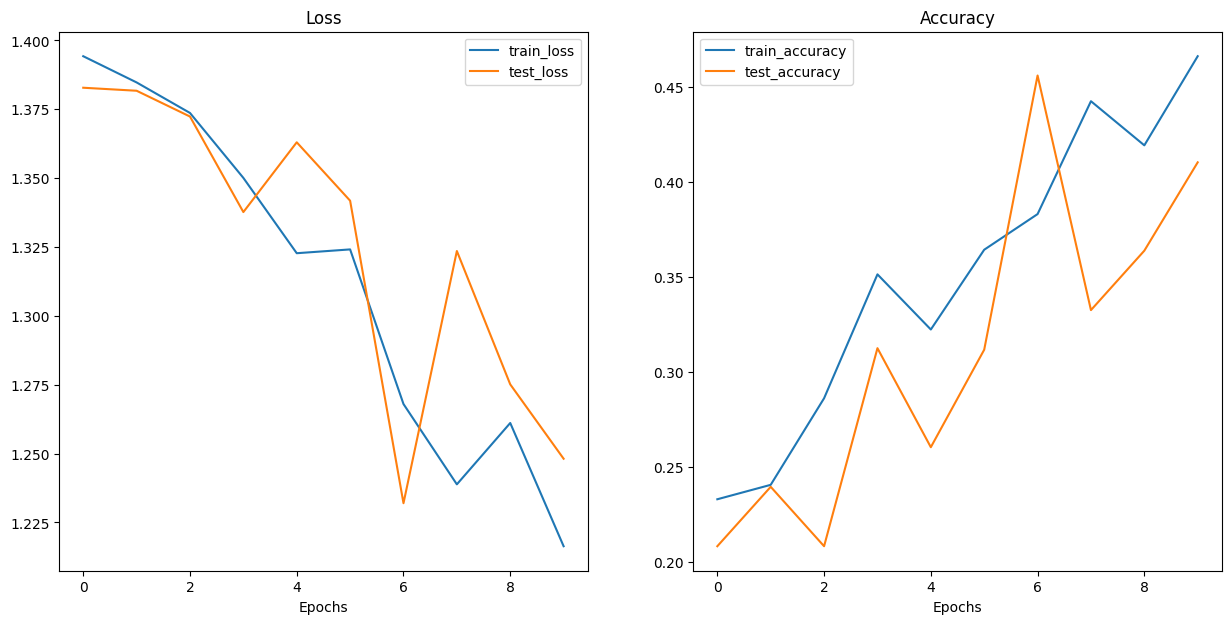

In [29]:
plot_loss_curves(model_0_results)

In [30]:
def make_predictions(model: torch.nn.Module, data: list):
    """
    data: [img_tensor, img_tensor, ...]  # Her biri [C, H, W]
    return: [N, num_classes] olasılık tensörü
    """
    pred_probs = []
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # [C, H, W] -> [1, C, H, W]
            sample = sample.unsqueeze(0)

            # Logits değerlerini al
            pred_logit = model(sample)    # shape: [1, num_classes]

            # Softmax ile olasılığa çevir
            prob = torch.softmax(pred_logit, dim=1)  # [1, num_classes]

            # Batch boyutunu sıkıştır
            pred_probs.append(prob.squeeze(0))       # [num_classes]

    # Tüm tahminleri birleştir → [N, num_classes]
    return torch.stack(pred_probs)

In [31]:
def show_random_predictions(model, dataset, class_names, n=9):
    model.eval()

    plt.figure(figsize=(4, 4))

    # Rastgele 9 index seç
    indices = random.sample(range(len(dataset)), n)

    with torch.inference_mode():
        for i, idx in enumerate(indices):
            img, true_label = dataset[idx]

            # Görüntüyü modele uygun hale getir
            img_input = img.unsqueeze(0)
            logits = model(img_input)
            pred_label = logits.argmax(dim=1).item()

            # Görseli çizdirmek için boyutları düzenle
            img_show = img.permute(1, 2, 0)

            # Tahmin doğru mu yanlış mı?
            correct = (pred_label == true_label)
            color = "green" if correct else "red"

            # Subplot oluştur
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_show)
            plt.axis("off")

            plt.title(
                f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}",
                color=color,
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

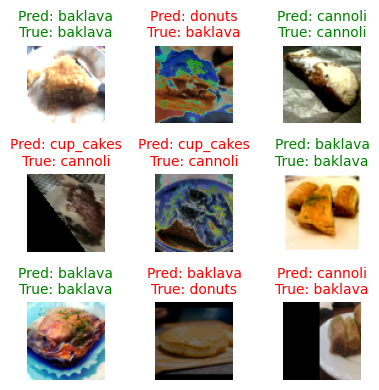

In [32]:
show_random_predictions(model_0, test_data, class_name)

In [33]:
# İnternetten bir baklava görseli bulup model üzerinde deneyelim
online_image_path = "baklava.jpg"
online_image_path

'baklava.jpg'

In [34]:
import torchvision

single_image = torchvision.io.read_image(str(online_image_path))
single_image

tensor([[[230, 230, 230,  ..., 229, 229, 229],
         [230, 230, 230,  ..., 229, 229, 229],
         [231, 231, 231,  ..., 229, 229, 229],
         ...,
         [217, 217, 217,  ..., 218, 218, 218],
         [216, 216, 216,  ..., 218, 218, 218],
         [215, 215, 215,  ..., 218, 218, 218]],

        [[232, 232, 232,  ..., 238, 238, 238],
         [232, 232, 232,  ..., 238, 238, 238],
         [233, 233, 233,  ..., 238, 238, 238],
         ...,
         [227, 227, 227,  ..., 228, 228, 228],
         [226, 226, 226,  ..., 228, 228, 228],
         [225, 225, 225,  ..., 228, 228, 228]],

        [[247, 247, 245,  ..., 245, 245, 245],
         [247, 247, 245,  ..., 245, 245, 245],
         [246, 246, 246,  ..., 245, 245, 245],
         ...,
         [239, 239, 239,  ..., 240, 240, 240],
         [238, 238, 238,  ..., 240, 240, 240],
         [237, 237, 237,  ..., 240, 240, 240]]], dtype=torch.uint8)

Okunan görsel tensor formatındadır. Ancak veri tipi `uint8` olduğu için piksel değerleri **0 ile 255** arasındadır.

Bizim modelimiz ise `torch.float32` tipinde ve **0 ile 1** aralığında ölçeklenmiş görüntü tensorleri bekler.

Bu yüzden görsele birkaç dönüşüm uygulamamız gerekir.

In [35]:
# Burada görselin veri tipini float32 olarak belirtiyoruz
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

# Piksel değerlerini 0-1 aralığına getirmek için 255'e bölüyoruz
single_image = single_image / 255

(np.float64(-0.5), np.float64(637.5), np.float64(479.5), np.float64(-0.5))

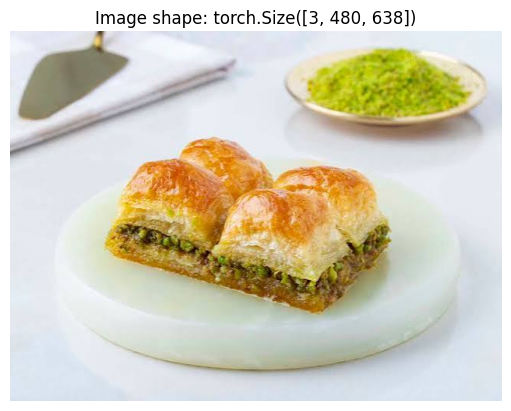

In [36]:
plt.imshow(single_image.permute(1, 2, 0))
plt.title(f"Image shape: {single_image.shape}")
plt.axis(False)

In [37]:
# Görsele resize transform işlemini de uygulamamız gerekiyor
single_image_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
])

In [38]:
# Hedef görsele transform işlemini uygula
single_image = single_image_transform(single_image)

single_image.shape

torch.Size([3, 64, 64])

In [39]:
single_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [40]:
single_image = single_image.unsqueeze(dim=0)

In [41]:
model_0.eval()

with torch.inference_mode():
    logits = model_0(single_image)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class:", class_name[pred_idx])

Predicted class: baklava


In [42]:
# Modelin accuracy değerini artırmak için veri sayısını artırabilirsin.
# Farklı data augmentation yöntemleri deneyebilirsin.
# Nöron sayısını değiştirebilir veya farklı bir model mimarisi kullanabilirsin.